In [ ]:
import pandas as pd
import numpy as np
import random

# Set seed agar hasil random tetap konsisten setiap kali dijalankan
np.random.seed(42)
random.seed(42)

# Jumlah data yang ingin dibuat
n_records = 1000

# Membuat fitur dasar
data = {
    'ID_Mahasiswa': [f'MHS{str(i).zfill(4)}' for i in range(1, n_records + 1)],
    'Tahun_Masuk': np.random.choice([2018, 2019, 2020, 2021, 2022], n_records),
    'Jalur_Masuk': np.random.choice(['SNMPTN', 'SBMPTN', 'Mandiri'], n_records, p=[0.3, 0.4, 0.3]),
    'Aktif_Organisasi': np.random.choice([0, 1], n_records, p=[0.6, 0.4]) # 1 = Ya, 0 = Tidak
}

df = pd.DataFrame(data)

# Inisialisasi list untuk fitur yang bergantung pada logika kelulusan
ipk_list = []
sks_list = []
mk_gagal_list = []
status_skripsi_list = []
jml_bimbingan_list = []
lama_studi_list = []
target_ontime_list = []

# Generate data dengan aturan logis (Rule-Based)
for idx, row in df.iterrows():
    # Tentukan status target terlebih dahulu (misal: 55% ontime, 45% tidak)
    is_ontime = np.random.choice([1, 0], p=[0.55, 0.45])
    target_ontime_list.append(is_ontime)

    if is_ontime == 1:
        # Jika Ontime (Lulus <= 4 tahun / 48 bulan)
        ipk = round(random.uniform(3.00, 4.00), 2)
        sks = 144
        mk_gagal = random.randint(0, 2)
        status_skripsi = 4 # 4 = Sudah Sidang/Lulus
        jml_bimbingan = random.randint(10, 18)
        lama_studi = random.randint(42, 48)
    else:
        # Jika Tidak Ontime (Lulus > 4 tahun)
        ipk = round(random.uniform(2.00, 3.10), 2)
        sks = random.choice([110, 120, 135, 140, 144])
        mk_gagal = random.randint(3, 8)
        status_skripsi = random.randint(0, 4) # Bisa jadi tertahan di Sempro (2) atau Semhas (3)
        jml_bimbingan = random.randint(2, 10) if status_skripsi < 4 else random.randint(15, 25)
        lama_studi = random.randint(49, 72) # Lama studi lebih dari 48 bulan

    ipk_list.append(ipk)
    sks_list.append(sks)
    mk_gagal_list.append(mk_gagal)
    status_skripsi_list.append(status_skripsi)
    jml_bimbingan_list.append(jml_bimbingan)
    lama_studi_list.append(lama_studi)

# Memasukkan list ke dalam DataFrame
df['IPK'] = ipk_list
df['SKS_Lulus'] = sks_list
df['Jumlah_MK_Gagal'] = mk_gagal_list
df['Status_Skripsi'] = status_skripsi_list
df['Jumlah_Bimbingan'] = jml_bimbingan_list
df['Lama_Masa_Studi_Bulan'] = lama_studi_list
df['Target_Ontime'] = target_ontime_list

# Menyimpan DataFrame ke dalam file CSV
file_name = 'dataset_kelulusan_1000.csv'
df.to_csv(file_name, index=False)

# Menampilkan 5 baris pertama untuk memastikan bentuk datanya
print(f"File {file_name} berhasil dibuat!")
display(df.head())

File dataset_kelulusan_1000.csv berhasil dibuat!


,ID_Mahasiswa,Tahun_Masuk,Jalur_Masuk,Aktif_Organisasi,IPK,SKS_Lulus,Jumlah_MK_Gagal,Status_Skripsi,Jumlah_Bimbingan,Lama_Masa_Studi_Bulan,Target_Ontime
0,MHS0001,2021,Mandiri,1,3.64,144,0,4,14,43,1
1,MHS0002,2022,SBMPTN,0,2.25,110,8,4,16,67,0
2,MHS0003,2020,SBMPTN,0,2.46,110,3,1,5,65,0
3,MHS0004,2022,Mandiri,0,3.60,144,2,4,13,47,1
4,MHS0005,2022,Mandiri,1,2.71,144,6,1,9,67,0


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('dataset_kelulusan_1000.csv')

In [3]:
# Menghapus missing value (data kosong)
df_clean = df.dropna()

In [4]:
# Menghapus duplikasi data
df_clean = df_clean.drop_duplicates()

In [5]:
# Menyamakan format data, misalnya memastikan semua teks Jalur_Masuk huruf kapital
df_clean['Jalur_Masuk'] = df_clean['Jalur_Masuk'].str.upper()

In [6]:
print("Data Cleaning Selesai. Jumlah baris saat ini:", len(df_clean))

Data Cleaning Selesai. Jumlah baris saat ini: 1000


In [7]:
# A. Rata IP: Karena di dataset kita menggunakan IPK, kita asumsikan IPK adalah representasi Rata-rata IP
df_clean['Rata_IP'] = df_clean['IPK']

In [8]:
# B. Progress Skripsi / SKS: Menghitung rasio tahapan skripsi dibandingkan dengan jumlah SKS yang sudah diambil
# Ditambahkan +1 pada SKS untuk menghindari pembagian dengan nol (zero division error) jika ada data anomali
df_clean['Progress_Skripsi_SKS'] = df_clean['Status_Skripsi'] / (df_clean['SKS_Lulus'] + 1)

In [9]:
# C. Tren IP: Dalam realita ini didapat dari selisih IP semester akhir dan awal.
# Karena dataset kita tidak punya data per semester, kita buat kolom simulasi Tren_IP sederhana sebagai contoh
# (Misal: mahasiswa aktif organisasi cenderung punya tren IP stabil/sedikit turun)
df_clean['Tren_IP'] = df_clean['IPK'] * 0.1

In [10]:
print("Fitur baru berhasil ditambahkan:", ['Rata_IP', 'Progress_Skripsi_SKS', 'Tren_IP'])

Fitur baru berhasil ditambahkan: ['Rata_IP', 'Progress_Skripsi_SKS', 'Tren_IP']


In [11]:
df_encoded = pd.get_dummies(df_clean, columns=['Jalur_Masuk'])

In [12]:
# Normalisasi: Mengubah skala angka yang terlalu besar agar seimbang (misal kolom Jumlah_Bimbingan dan SKS_Lulus)
scaler = MinMaxScaler()
df_encoded[['Jumlah_Bimbingan', 'SKS_Lulus']] = scaler.fit_transform(df_encoded[['Jumlah_Bimbingan', 'SKS_Lulus']])

print("Encoding dan Normalisasi selesai dilakukan.")

Encoding dan Normalisasi selesai dilakukan.


In [13]:
# X = Kumpulan Kriteria / Fitur Model
X = df_encoded.drop(columns=['ID_Mahasiswa', 'Lama_Masa_Studi_Bulan', 'Target_Ontime'])

In [14]:
# y = Target / Label yang ingin diprediksi
y = df_encoded['Target_Ontime']

In [15]:
print("Fitur yang siap dimasukkan ke model (X):")
print(X.columns.tolist())

Fitur yang siap dimasukkan ke model (X):
['Tahun_Masuk', 'Aktif_Organisasi', 'IPK', 'SKS_Lulus', 'Jumlah_MK_Gagal', 'Status_Skripsi', 'Jumlah_Bimbingan', 'Rata_IP', 'Progress_Skripsi_SKS', 'Tren_IP', 'Jalur_Masuk_MANDIRI', 'Jalur_Masuk_SBMPTN', 'Jalur_Masuk_SNMPTN']


In [16]:
print("--- 5. MODELING (MACHINE LEARNING) ---")
# Proses modeling: Split Data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- 5. MODELING (MACHINE LEARNING) ---


In [17]:
print(f"Jumlah Data Training : {len(X_train)} baris")
print(f"Jumlah Data Testing  : {len(X_test)} baris")

Jumlah Data Training : 800 baris
Jumlah Data Testing  : 200 baris


In [18]:
# Algoritma Prediksi: Inisialisasi model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [19]:
# Training Model AI menggunakan data training
model_rf.fit(X_train, y_train)
print("Training Model AI berhasil diselesaikan!")

Training Model AI berhasil diselesaikan!


In [20]:
# Prediksi menggunakan data testing
y_pred = model_rf.predict(X_test)

In [21]:
print("\n--- 6. EVALUATION ---")
# Metode Evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)


--- 6. EVALUATION ---


In [22]:
# Insight / Informasi: Faktor / Kriteria yang paling berpengaruh
importances = model_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Fitur': X.columns, 'Bobot_Pengaruh': importances})
feature_importance_df = feature_importance_df.sort_values(by='Bobot_Pengaruh', ascending=False)

In [23]:
print("\nInsight: Faktor yang paling berpengaruh terhadap kelulusan:")
print(feature_importance_df.to_string(index=False))


Insight: Faktor yang paling berpengaruh terhadap kelulusan:
               Fitur  Bobot_Pengaruh
     Jumlah_MK_Gagal        0.323973
             Rata_IP        0.167569
             Tren_IP        0.144344
                 IPK        0.131649
      Status_Skripsi        0.078765
           SKS_Lulus        0.068521
Progress_Skripsi_SKS        0.047451
    Jumlah_Bimbingan        0.036922
         Tahun_Masuk        0.000563
  Jalur_Masuk_SBMPTN        0.000097
  Jalur_Masuk_SNMPTN        0.000082
    Aktif_Organisasi        0.000037
 Jalur_Masuk_MANDIRI        0.000027


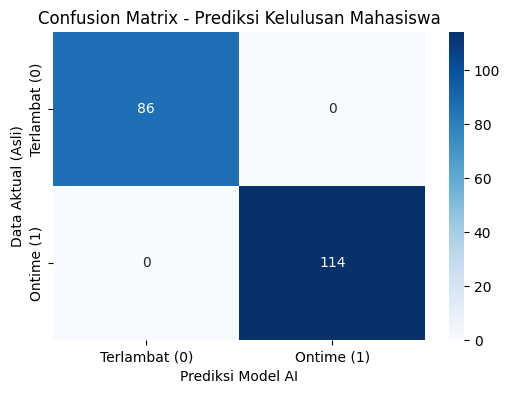

In [24]:
# Menampilkan Confusion matrix  untuk melihat apakah Model Bias (salah baca pola)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Terlambat (0)', 'Ontime (1)'],
            yticklabels=['Terlambat (0)', 'Ontime (1)'])
plt.title('Confusion Matrix - Prediksi Kelulusan Mahasiswa')
plt.xlabel('Prediksi Model AI')
plt.ylabel('Data Aktual (Asli)')
plt.show()

/tmp/ipykernel_8695/1379982673.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=scores, palette='viridis')


Text(0, 0.5, 'Skor')

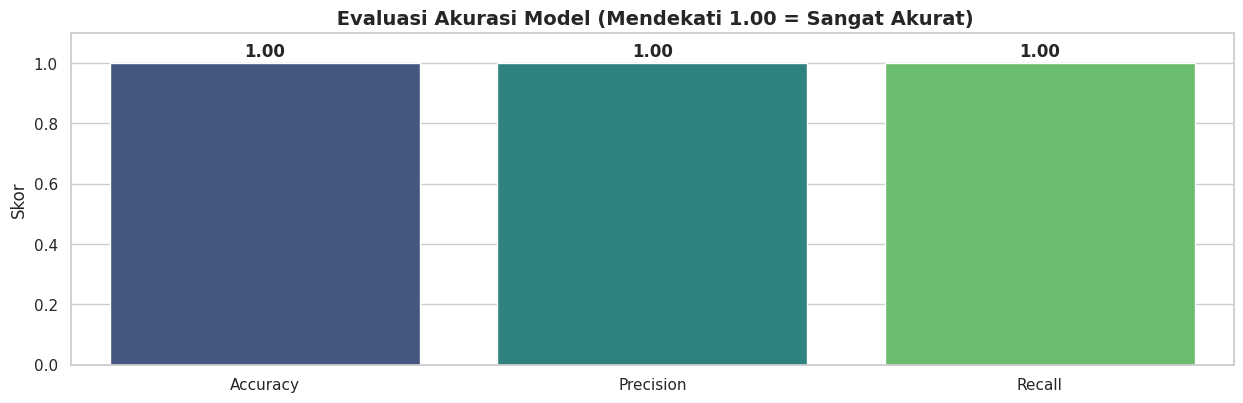

In [37]:
# Mengatur gaya visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")

# Membuat grid untuk 5 visualisasi
fig = plt.figure(figsize=(15, 25))

# ==========================================
# 1. Apakah Training Model Sudah Akurat? (Bar Chart Metrik)
# ==========================================
plt.subplot(5, 1, 1)
metrics = ['Accuracy', 'Precision', 'Recall']
scores = [acc, prec, rec]
sns.barplot(x=metrics, y=scores, palette='viridis')
plt.ylim(0, 1.1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')
plt.title(' Evaluasi Akurasi Model (Mendekati 1.00 = Sangat Akurat)', fontsize=14, fontweight='bold')
plt.ylabel('Skor')

/tmp/ipykernel_8695/652559053.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediksi_Kelulusan', y='IPK', data=df_eval, palette='Set2')


Text(0.5, 1.0, 'Kelogisan Model: Distribusi IPK berdasarkan Tebakan AI\n(Masuk akal jika IPK tinggi diprediksi Ontime)')

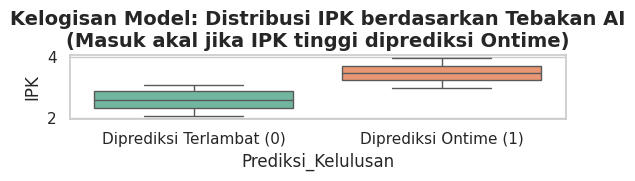

In [26]:
# 3. Apakah Model Masuk Akal? (Distribusi IPK berdasarkan Prediksi)
# ==========================================
plt.subplot(5, 1, 3)
# Menggabungkan data test dengan hasil prediksi untuk visualisasi
df_eval = X_test.copy()
df_eval['Prediksi_Kelulusan'] = y_pred

# Kita cek kelogisan: Apakah model menebak "Ontime" untuk mahasiswa dengan IPK tinggi?
sns.boxplot(x='Prediksi_Kelulusan', y='IPK', data=df_eval, palette='Set2')
plt.xticks([0, 1], ['Diprediksi Terlambat (0)', 'Diprediksi Ontime (1)'])
plt.title('Kelogisan Model: Distribusi IPK berdasarkan Tebakan AI\n(Masuk akal jika IPK tinggi diprediksi Ontime)', fontsize=14, fontweight='bold')

/tmp/ipykernel_8695/3738028657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bobot_Pengaruh', y='Fitur', data=top_features, palette='magma')


Text(0, 0.5, 'Kriteria')

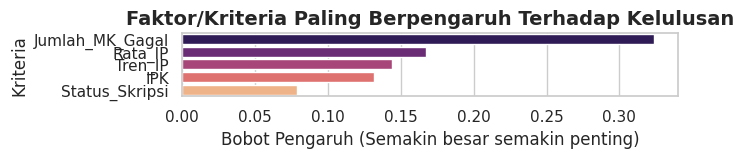

In [27]:
plt.subplot(5, 1, 4)
# Mengambil 5 fitur paling berpengaruh saja agar rapi
top_features = feature_importance_df.head(5)
sns.barplot(x='Bobot_Pengaruh', y='Fitur', data=top_features, palette='magma')
plt.title('Faktor/Kriteria Paling Berpengaruh Terhadap Kelulusan', fontsize=14, fontweight='bold')
plt.xlabel('Bobot Pengaruh (Semakin besar semakin penting)')
plt.ylabel('Kriteria')

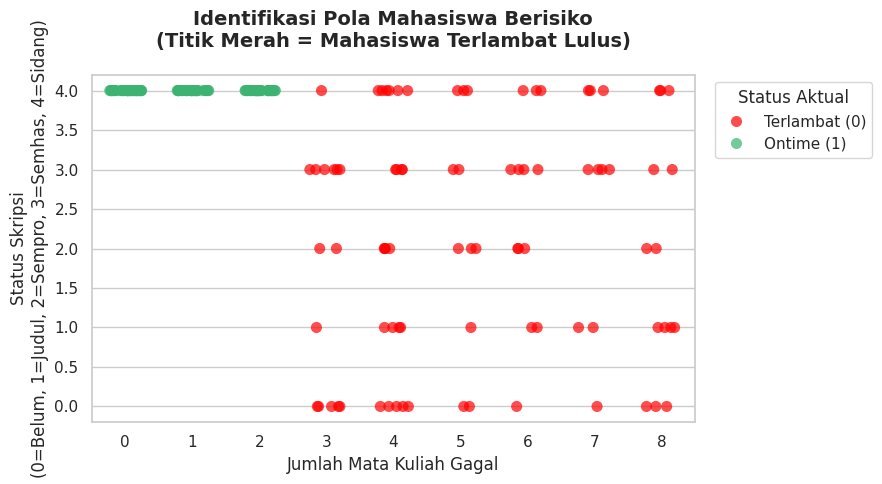

In [28]:
plt.figure(figsize=(9, 5))

# Menggunakan stripplot dengan fitur 'jitter' agar data diskrit tidak saling tumpuk
sns.stripplot(
    x='Jumlah_MK_Gagal',
    y='Status_Skripsi',
    hue=y_test,
    data=X_test,
    palette={0: 'red', 1: 'mediumseagreen'}, # 0 = Merah (Bahaya/Terlambat), 1 = Hijau (Aman/Ontime)
    size=8,
    alpha=0.7,   # Transparansi agar titik yang numpuk warnanya lebih pekat
    jitter=0.25  # Menambahkan sebaran agar titik tidak di satu garis lurus
)

# Merapikan Judul dan Label
plt.title('Identifikasi Pola Mahasiswa Berisiko\n(Titik Merah = Mahasiswa Terlambat Lulus)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jumlah Mata Kuliah Gagal', fontsize=12)
plt.ylabel('Status Skripsi\n(0=Belum, 1=Judul, 2=Sempro, 3=Semhas, 4=Sidang)', fontsize=12)

# Merapikan Legend agar tidak menutupi grafik
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Terlambat (0)', 'Ontime (1)'], title='Status Aktual',
           bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [29]:
import joblib

# Menyimpan model Random Forest
joblib.dump(model_rf, 'model_kelulusan_rf.pkl')

# Menyimpan Scaler (karena kamu menormalisasi Jumlah_Bimbingan & SKS_Lulus)
joblib.dump(scaler, 'scaler_kelulusan.pkl')

# Menyimpan daftar kolom (X.columns) agar input aplikasi cocok dengan model
joblib.dump(X.columns.tolist(), 'kolom_fitur.pkl')

print("Model, Scaler, dan Kolom berhasil disimpan!")

Model, Scaler, dan Kolom berhasil disimpan!


In [30]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 61.3 MB/s eta 0:00:00


In [31]:
import datetime

In [32]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import datetime # <--- INI YANG BIKIN ERROR TADI, HARUS DITAMBAHKAN DI SINI

st.set_page_config(page_title="Sistem Prediksi Kelulusan", layout="wide")

@st.cache_resource
def load_components():
    model = joblib.load('model_kelulusan_rf.pkl')
    scaler = joblib.load('scaler_kelulusan.pkl')
    fitur_cols = joblib.load('kolom_fitur.pkl')
    return model, scaler, fitur_cols

model, scaler, fitur_cols = load_components()

def berikan_rekomendasi(prediksi, mk_gagal, ipk):
    if prediksi == 0:
        if mk_gagal > 2:
            return "Tindakan Cepat: Evaluasi ulang MK yang gagal, pertimbangkan ambil semester pendek. Jadwalkan bimbingan akademik."
        elif ipk < 3.0:
            return "Tindakan: Perbaikan nilai di semester ini. Mahasiswa diwajibkan menghadap Kaprodi."
        else:
            return "Tindakan: Pantau progres skripsi secara ketat, tambahkan frekuensi bimbingan."
    else:
        return "Tindakan: Pertahankan performa, fokus pada percepatan sidang skripsi."

st.sidebar.title("Login Sistem")
role = st.sidebar.selectbox("Pilih Peran User:", ["Pimpinan (Rektor/Dekan/Kaprodi)", "Mahasiswa"])
st.sidebar.markdown("---")
st.sidebar.info("Aplikasi Early Warning System (EWS) Prediksi Kelulusan Mahasiswa.")

if role == "Pimpinan (Rektor/Dekan/Kaprodi)":
    st.title("🎓 Dashboard Pimpinan & Early Warning System")
    st.markdown("### Upload Data Mahasiswa Aktif")
    uploaded_file = st.file_uploader("Upload file CSV data mahasiswa", type=['csv'])

    if uploaded_file is not None:
        df_raw = pd.read_csv(uploaded_file)
        df_clean = df_raw.dropna().copy()

        if 'Rata_IP' not in df_clean.columns: df_clean['Rata_IP'] = df_clean['IPK']
        if 'Progress_Skripsi_SKS' not in df_clean.columns: df_clean['Progress_Skripsi_SKS'] = df_clean['Status_Skripsi'] / (df_clean['SKS_Lulus'] + 1)
        if 'Tren_IP' not in df_clean.columns: df_clean['Tren_IP'] = df_clean['IPK'] * 0.1

        df_encoded = pd.get_dummies(df_clean, columns=['Jalur_Masuk'])

        for col in fitur_cols:
            if col not in df_encoded.columns: df_encoded[col] = 0
        df_ready = df_encoded[fitur_cols].copy()

        df_ready[['Jumlah_Bimbingan', 'SKS_Lulus']] = scaler.transform(df_ready[['Jumlah_Bimbingan', 'SKS_Lulus']])

        prediksi = model.predict(df_ready)
        df_clean['Prediksi_Lulus'] = prediksi
        df_clean['Status_Prediksi'] = df_clean['Prediksi_Lulus'].map({0: 'Terlambat', 1: 'Ontime'})
        df_clean['Rekomendasi_Tindakan'] = df_clean.apply(
            lambda x: berikan_rekomendasi(x['Prediksi_Lulus'], x['Jumlah_MK_Gagal'], x['IPK']), axis=1
        )

        tab1, tab2, tab3 = st.tabs(["📊 Dashboard Monitoring", "⚠️ Early Warning System", "📋 Seluruh Data"])

        with tab1:
            col1, col2 = st.columns(2)
            jml_ontime = len(df_clean[df_clean['Prediksi_Lulus'] == 1])
            jml_telat = len(df_clean[df_clean['Prediksi_Lulus'] == 0])
            col1.metric("Prediksi Lulus Ontime", f"{jml_ontime} Mhs")
            col2.metric("Berisiko Terlambat Lulus", f"{jml_telat} Mhs", delta="- Berisiko", delta_color="inverse")

            fig, ax = plt.subplots(figsize=(3, 3))
            ax.pie([jml_ontime, jml_telat], labels=['Ontime', 'Terlambat'], autopct='%1.1f%%', colors=['#2ecc71', '#ff4d4d'])
            st.pyplot(fig)

        with tab2:
            st.markdown("### Daftar Mahasiswa Berisiko Lulus Terlambat")
            df_berisiko = df_clean[df_clean['Prediksi_Lulus'] == 0][['ID_Mahasiswa', 'IPK', 'Jumlah_MK_Gagal', 'Status_Skripsi', 'Rekomendasi_Tindakan']]
            st.dataframe(df_berisiko, use_container_width=True)

        with tab3:
            st.dataframe(df_clean[['ID_Mahasiswa', 'IPK', 'Status_Prediksi', 'Rekomendasi_Tindakan']])

elif role == "Mahasiswa":
    st.title("👨‍🎓 Cek Status Kelulusan Mandiri")

    with st.form("form_mhs"):
        col1, col2 = st.columns(2)
        with col1:
            ipk = st.number_input("IPK Saat Ini", min_value=0.0, max_value=4.0, value=3.0)
            sks = st.number_input("Total SKS Lulus", min_value=0, max_value=160, value=120)
            mk_gagal = st.number_input("Jumlah Mata Kuliah Gagal/Diulang", min_value=0, value=0)

            # --- BAGIAN REALTIME TAHUN MASUK ---
            tahun_sekarang = datetime.datetime.now().year
            tahun_default = tahun_sekarang - 4
            tahun = st.number_input("Tahun Masuk", min_value=2010, max_value=tahun_sekarang, value=tahun_default)
            # ------------------------------------

            jalur = st.selectbox("Jalur Masuk", ["SNMPTN", "SBMPTN", "MANDIRI"])

        with col2:
            organisasi = st.selectbox("Aktif Organisasi?", [1, 0], format_func=lambda x: "Ya" if x == 1 else "Tidak")
            status_skripsi = st.selectbox("Status Skripsi", [0, 1, 2, 3, 4], format_func=lambda x: {0:"Belum", 1:"Pengajuan Judul", 2:"Sempro", 3:"Semhas", 4:"Sidang"}[x])
            bimbingan = st.number_input("Jumlah Bimbingan Skripsi", min_value=0, value=0)

        submit = st.form_submit_button("Prediksi")

    if submit:
        input_data = pd.DataFrame([{
            'Tahun_Masuk': tahun, 'Aktif_Organisasi': organisasi, 'IPK': ipk, 'SKS_Lulus': sks,
            'Jumlah_MK_Gagal': mk_gagal, 'Status_Skripsi': status_skripsi, 'Jumlah_Bimbingan': bimbingan,
            'Rata_IP': ipk, 'Progress_Skripsi_SKS': status_skripsi / (sks + 1), 'Tren_IP': ipk * 0.1,
            'Jalur_Masuk_MANDIRI': 1 if jalur == "MANDIRI" else 0,
            'Jalur_Masuk_SBMPTN': 1 if jalur == "SBMPTN" else 0,
            'Jalur_Masuk_SNMPTN': 1 if jalur == "SNMPTN" else 0
        }])

        for col in fitur_cols:
            if col not in input_data.columns: input_data[col] = 0
        input_ready = input_data[fitur_cols].copy()
        input_ready[['Jumlah_Bimbingan', 'SKS_Lulus']] = scaler.transform(input_ready[['Jumlah_Bimbingan', 'SKS_Lulus']])

        hasil = model.predict(input_ready)[0]

        st.markdown("---")
        if hasil == 1:
            st.success("🎉 Hasil Prediksi: LULUS TEPAT WAKTU (Ontime)!")
            st.info(berikan_rekomendasi(1, mk_gagal, ipk))
        else:
            st.error("⚠️ Hasil Prediksi: Berisiko LULUS TERLAMBAT.")
            st.warning(berikan_rekomendasi(0, mk_gagal, ipk))

Writing app.py


In [33]:
import urllib
print("Catat/Copy IP Address ini untuk Password LocalTunnel:")
print(urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Catat/Copy IP Address ini untuk Password LocalTunnel:
34.12.108.170


In [34]:
!pip install pyngrok -q

In [35]:
!ngrok config add-authtoken 3Da01l7t4rMVwRXRt4Vwuryd4Cu_3tbKiHxGYtnjGgYfvPn5M

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [36]:
from pyngrok import ngrok
import os
import time

# Mematikan proses ngrok yang mungkin masih tersisa sebelumnya
ngrok.kill()

# Menjalankan Streamlit secara background
os.system("nohup streamlit run app.py &")

# Beri jeda 3 detik agar Streamlit menyala dengan sempurna
time.sleep(3)

# Membuka tunnel Ngrok di port 8501 (port default Streamlit)
public_url = ngrok.connect(8501).public_url
print(f"🚀 BERHASIL! Klik link ini untuk membuka Dashboard AI kamu:")
print(public_url)

🚀 BERHASIL! Klik link ini untuk membuka Dashboard AI kamu:
https://fiber-ascertain-clamshell.ngrok-free.dev
